# Product Feature Adoption Experiment — A/B Testing Simulation

## Objective
This project simulates an A/B test to evaluate whether a new product feature increases user engagement.

## Experiment Design
- Control group: users with the old product experience
- Treatment group: users exposed to the new feature

## Key metric
- Session time
- Number of clicks

## Goal
Estimate whether the new feature leads to a statistically significant improvement in user engagement.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

In [26]:
np.random.seed(42)

n = 1000

group = np.random.choice(['control', 'treatment'], size=n)

session_time = np.where(
    group == 'control',
    np.random.normal(5.0, 1.5, n),
    np.random.normal(6.2, 1.5, n)
)

clicks = np.where(
    group == 'control',
    np.random.poisson(3, n),
    np.random.poisson(4, n)
)

df = pd.DataFrame({
    'user_id': range(1, n + 1),
    'group': group,
    'session_time': session_time,
    'clicks': clicks
})

df.head()

,user_id,group,session_time,clicks
0,1,control,5.512634,2
1,2,treatment,8.542267,5
2,3,control,6.425636,2
3,4,control,4.134645,2
4,5,control,3.652378,3


In [27]:
df['group'].value_counts()

group
treatment    510
control      490
Name: count, dtype: int64

In [28]:
df.groupby("group")[["session_time", "clicks"]].mean()

,session_time,clicks
group,,
control,5.069267,3.002041
treatment,6.231301,3.941176


In [29]:
control_mean = df[df["group"]=="control"]["session_time"].mean()
treatment_mean = df[df["group"]=="treatment"]["session_time"].mean()

effect = treatment_mean - control_mean

effect

np.float64(1.162034472440836)

In [30]:
control = df[df["group"]=="control"]["session_time"]
treatment = df[df["group"]=="treatment"]["session_time"]

t_stat, p_value = stats.ttest_ind(treatment, control)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 12.423714766751319
p-value: 4.6968895720133775e-33


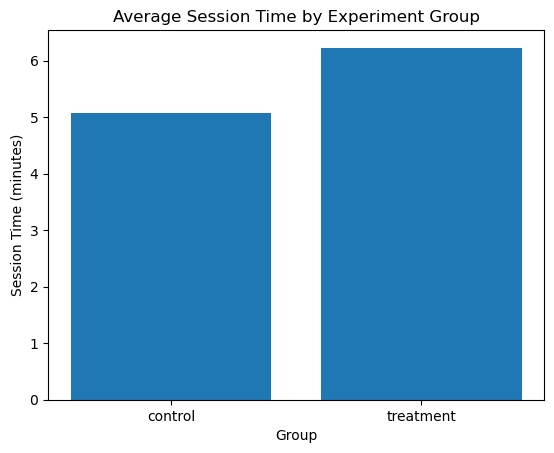

In [31]:
mean_session = df.groupby("group")["session_time"].mean()

plt.bar(mean_session.index, mean_session.values)

plt.title("Average Session Time by Experiment Group")
plt.ylabel("Session Time (minutes)")
plt.xlabel("Group")

plt.show()

In [32]:
df["treatment"] = (df["group"] == "treatment").astype(int)

model = smf.ols("session_time ~ treatment", data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           session_time   R-squared:                       0.134
Model:                            OLS   Adj. R-squared:                  0.133
Method:                 Least Squares   F-statistic:                     154.3
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           4.70e-33
Time:                        14:14:48   Log-Likelihood:                -1809.0
No. Observations:                1000   AIC:                             3622.
Df Residuals:                     998   BIC:                             3632.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.0693      0.067     75.891      0.0

### Engagement Analysis

The treatment group showed higher engagement than the control group across the primary metrics.

- Average session time increased from 5.07 to 6.23 minutes
- Average clicks increased from 3.00 to 3.94
- Estimated treatment effect on session time: 1.16 minutes
- T-test p-value: < 0.001

These results suggest that the new feature meaningfully improves short-term user engagement.

In [33]:
retention = np.where(
    group == "control",
    np.random.binomial(1, 0.30, n),   # 30% retention
    np.random.binomial(1, 0.38, n)    # new feature increase retention
)

df["retained_next_day"] = retention

In [34]:
df.groupby("group")["retained_next_day"].mean()

group
control      0.273469
treatment    0.360784
Name: retained_next_day, dtype: float64

In [35]:
control_ret = df[df["group"]=="control"]["retained_next_day"]
treat_ret = df[df["group"]=="treatment"]["retained_next_day"]

stats.ttest_ind(treat_ret, control_ret)

TtestResult(statistic=np.float64(2.9740424580319993), pvalue=np.float64(0.0030097368473909394), df=np.float64(998.0))

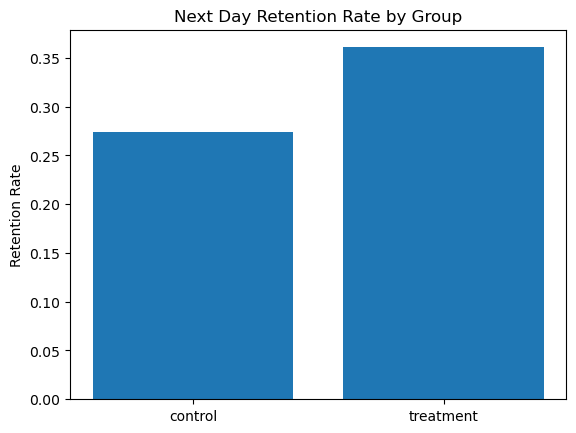

In [36]:
mean_ret = df.groupby("group")["retained_next_day"].mean()

plt.bar(mean_ret.index, mean_ret.values)

plt.title("Next Day Retention Rate by Group")
plt.ylabel("Retention Rate")

plt.show()

### Retention Analysis

The treatment group achieved a higher next-day retention rate than the control group.

- Control retention: 27.35%
- Treatment retention: 36.08%
- Absolute uplift: 8.73 percentage points
- P-value: 0.003

This suggests that the new feature has a positive and statistically significant effect on short-term user retention.

## Final Conclusion

This simulated A/B test suggests that the new feature improves both user engagement and short-term retention.

### Key Results
- Average session time increased by 1.16 minutes
- Average clicks increased from 3.00 to 3.94
- Next-day retention increased by 8.73 percentage points
- The observed effects were statistically significant

### Recommendation
Based on the simulated evidence, the product team should consider rolling out the feature to a broader user base. Future analysis should continue to monitor long-term retention and downstream user behaviour.